### Muerte súbita - proyectos legislativos

Para controlar la visualizacion usar:
* https://www.color-blindness.com/coblis-color-blindness-simulator/
* https://colorbrewer2.org/#type=diverging&scheme=BrBG&n=3

In [1]:
# Cargar las librerías necesarias
from dotenv import load_dotenv
import pandas as pd
import pickle 
import os
import sys
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
load_dotenv() 

True

In [2]:
HEALTH_CYAN = "#0077A8"   # celeste medio
GRAY_MAIN   = "#8F8F8F"
GRAY_LIGHT  = "#E0E0E0"
GRAY_DARK   = "#3A3A3A"

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import locale

#locale.setlocale(locale.LC_ALL, 'es_AR.UTF-8')
#'es_ES.UTF-8'
#'es_ES'
#'spanish'

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette=[HEALTH_CYAN, GRAY_MAIN, GRAY_LIGHT, GRAY_DARK]
)

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.titlesize": 14,
    "font.size": 18,
    "axes.titleweight": "bold",
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "axes.edgecolor": "#2B2B2B",
    "axes.labelcolor": "#2B2B2B",
    "text.color": "#2B2B2B",
    "grid.color": "#E5E5E5",
    "grid.linestyle": "--",
    "grid.alpha": 0.7,
    "legend.fontsize": 18,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white"
})


### Lectura de datos


In [4]:
# Configurar path
load_dotenv() # Cargar las variables de entorno del archivo .env
BASE_DIR =  os.getenv("DIR_BASE")
RESULTADOS_DIR = os.getenv("DIR_DATOS_PROCESADOS") # Acceder a las variables de entorno
sys.path.append(BASE_DIR)
sys.path.append(RESULTADOS_DIR)

pd.set_option('display.max_colwidth', None)

In [5]:
# vivir','morir','capacitar','capacita',
ms_palabras = ['muerte_subita' ,'desfibrilador','desfibracion','cardiovascular','cardioasistido','dea','dispositivo', 'muerte','vida','capacitacion', 'emergencia','supervivencia','reanimacion','prevencion','incidencia','deportivo']


In [6]:
print("Cantidad de palabras asociadas:",len(ms_palabras))

Cantidad de palabras asociadas: 16


**Proyectos de ley sobre salud entre 2009-2024**

In [7]:
with open(RESULTADOS_DIR +'ley_df.pkl', 'rb') as file: ## Para tener los textos procesados
    ley_df = pickle.load(file)
print(ley_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33097 entries, 0 to 33096
Data columns (total 41 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   Proyecto.ID                         33097 non-null  category      
 1   Título                              33097 non-null  category      
 2   Publicación.Fecha                   33097 non-null  datetime64[ns]
 3   Publicación.ID                      33097 non-null  category      
 4   Exp..Diputados                      33097 non-null  category      
 5   Tipo                                33097 non-null  category      
 6   Max_Orden                           33097 non-null  int64         
 7   Proyecto_girado_a_comisiones_SALUD  33097 non-null  float64       
 8   Proyecto_SALUD                      33097 non-null  float64       
 9   Resultado                           33097 non-null  category      
 10  Tiene_info_movimiento 

In [8]:
ms_palabras # Diccionario conceptualmente heterogéneo

['muerte_subita',
 'desfibrilador',
 'desfibracion',
 'cardiovascular',
 'cardioasistido',
 'dea',
 'dispositivo',
 'muerte',
 'vida',
 'capacitacion',
 'emergencia',
 'supervivencia',
 'reanimacion',
 'prevencion',
 'incidencia',
 'deportivo']

### Análisis descriptivo básico

In [9]:
ms_palabras_estricto = ['muerte_subita',
 'desfibrilador',
 'desfibracion',
 'dea',
 'reanimacion',
 'cardiovascular','cardioasistido'
                        
]

In [10]:
pattern = "|".join([rf"\b{palabra}\b" for palabra in ms_palabras_estricto])
ms_estricto_df = ley_df[ley_df["Título normalizado"].str.contains(pattern, case=False, na=False)]
ms_estricto_df.shape

(80, 41)

In [11]:
ley_df['Proyecto_MS_especifico'] = 0

ley_df.loc[(ley_df['Proyecto.ID'].isin(list(ms_estricto_df['Proyecto.ID'].values)) & (ley_df['Proyecto_SALUD']==1) ), 'Proyecto_MS_especifico'] = 1

In [12]:
ley_df[ley_df['Proyecto_MS_especifico']==1].shape #  Control #### ojo 52 proyectos de salud y con las palabras pero hay 80 con esas palabras

(52, 42)

In [13]:
# Función para preparar datos
def preparar_resumen_salud(df):

    # Preparar datos
    summary_df = df.groupby('Periodo').agg(
        total_proyectos=('Proyecto.ID', 'count'),
        proyectos_salud=('Proyecto_SALUD', 'sum'),
        proyectos_ms= ('Proyecto_MS', 'sum'),
        proyectos_ms_esp =('Proyecto_MS_especifico', 'sum')
    ).reset_index()
    
    summary_df['pct_salud'] = (summary_df['proyectos_salud'] / summary_df['total_proyectos']) * 100
    summary_df['pct_ms'] = (summary_df['proyectos_ms'] / summary_df['proyectos_salud']) * 100
    summary_df['pct_msE'] = (summary_df['proyectos_ms_esp'] / summary_df['proyectos_salud']) * 100
    summary_df['proyectos_nosalud'] = summary_df['total_proyectos'] -  summary_df['proyectos_salud']
    summary_df['proyectos_no_saludms'] = summary_df['proyectos_salud'] -  summary_df['proyectos_ms']
    summary_df['proyectos_no_saludmsesp'] = summary_df['proyectos_ms'] -  summary_df['proyectos_ms_esp']
    summary_df['pct_msNE'] = (summary_df['proyectos_no_saludmsesp'] / summary_df['proyectos_salud']) * 100
    
    # Datos para gráficos de torta
    total_proyectos = summary_df['total_proyectos'].sum()
    total_salud = summary_df['proyectos_salud'].sum()
    total_ms = summary_df['proyectos_ms'].sum()
    total_ms_esp = summary_df['proyectos_ms_esp'].sum()
    total_no_salud = total_proyectos - total_salud
    total_no_mssalud = total_salud - total_ms
    
    return summary_df, total_proyectos, total_salud, total_ms,total_ms_esp,total_no_salud,total_no_mssalud

In [14]:
summary1_df, total_proyectos1, total_salud1, total_ms1, total_ms_esp1, total_no_salud1,total_no_mssalud1 = preparar_resumen_salud(ley_df) # Para controlar

In [15]:
(total_ms_esp1/total_proyectos1)*100

0.15711393781913768

In [16]:
print( total_proyectos1, total_salud1, total_ms1, total_ms_esp1,total_no_salud1,total_no_mssalud1) # LEY - SALUD - MS -- NO SALUD - NO MS
summary1_df

33097 2848.0 523 52 30249.0 2325.0


,Periodo,total_proyectos,proyectos_salud,proyectos_ms,proyectos_ms_esp,pct_salud,pct_ms,pct_msE,proyectos_nosalud,proyectos_no_saludms,proyectos_no_saludmsesp,pct_msNE
0,127,1721,151.0,40,1,8.773969,26.490066,0.662252,1570.0,111.0,39,25.827815
1,128,2239,164.0,23,1,7.324699,14.024390,0.609756,2075.0,141.0,22,13.414634
2,129,1541,144.0,32,2,9.344581,22.222222,1.388889,1397.0,112.0,30,20.833333
3,130,2164,150.0,23,3,6.931608,15.333333,2.000000,2014.0,127.0,20,13.333333
4,131,1873,167.0,30,3,8.916177,17.964072,1.796407,1706.0,137.0,27,16.167665
5,132,3001,225.0,32,7,7.497501,14.222222,3.111111,2776.0,193.0,25,11.111111
6,133,1996,182.0,47,6,9.118236,25.824176,3.296703,1814.0,135.0,41,22.527473
7,134,2763,196.0,27,4,7.093739,13.775510,2.040816,2567.0,169.0,23,11.734694
8,135,2437,181.0,28,3,7.427165,15.469613,1.657459,2256.0,153.0,25,13.812155
9,136,2805,225.0,32,3,8.021390,14.222222,1.333333,2580.0,193.0,29,12.888889


In [17]:
# Función personalizada para mostrar valor y porcentaje con formato accesible
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return (
            f"{locale.format_string('%d', val, grouping=True)}\n"
            f"({locale.format_string('%.2f', pct)}%)"
        )
        #return f'{val:,}\n({pct:.2f}%)'
    return my_autopct


# Función para generar gráfica
def plot_torta_salud(labels_pie1,sizes_pie1,colors_pie1,figfile):

    fig, ax = plt.subplots(1, 1, figsize=(14, 10))  # Tamaño aumentado para mejor legibilidad
    # Crear el gráfico de torta

    wedges, texts, autotexts = ax.pie(
        sizes_pie1,
        labels=labels_pie1,
        colors=colors_pie1,
        autopct=make_autopct(sizes_pie1),
        startangle=90,
        pctdistance=1.15,
        labeldistance=1.05
        #textprops={'fontsize': 14}
    )
    
    
    # Alinear textos de labels y porcentajes a la izquierda
    for text in texts:
        text.set_fontsize(18)
        text.set_ha('left')
    
    
    for autotext in autotexts:
        autotext.set_ha('left')
        autotext.set_fontsize(18)
    
    # Forzar alineación vertical tipo columna
    for i, (text, autotext) in enumerate(zip(texts, autotexts)):
        x_text, y_text = text.get_position()
        x_auto, y_auto = autotext.get_position()
    
        # Forzar misma X para todos (columna a la derecha del gráfico)
        new_x = .50
        text.set_position((new_x, y_text))
        autotext.set_position((new_x, y_auto))

    # Reordenar visualmente SIN forzar columna
    for text, autotext in zip(texts, autotexts):
        x, y = text.get_position()
    
        # label un poco más arriba
        text.set_position((x, y + 0.1))
    
        # valor + porcentaje un poco más abajo
        autotext.set_position((x, y - 0.05))
    #ax.set_title('Distribución porcentual de Proyectos legislativos según clasificación (comisión cabecera) \n', pad=20, fontsize=14,fontweight='bold')
    #ax.axis('equal')
    
    
    # --- AJUSTES FINALES ---
    plt.tight_layout(pad=3)
    plt.subplots_adjust(bottom=0.25, right=0.85)  # Más espacio para leyenda y texto
    
    # Guardar en alta calidad para accesibilidad
    # BASE_DIR+'imagenes/proyectosTotalvsSalud_accesible.png'
    plt.savefig( figfile, 
                dpi=300, bbox_inches='tight', 
                facecolor='white', edgecolor='none')
    
    
    plt.show()
    # Limpiar para próximos gráficos
    plt.cla()
    plt.clf()
    plt.close(fig)

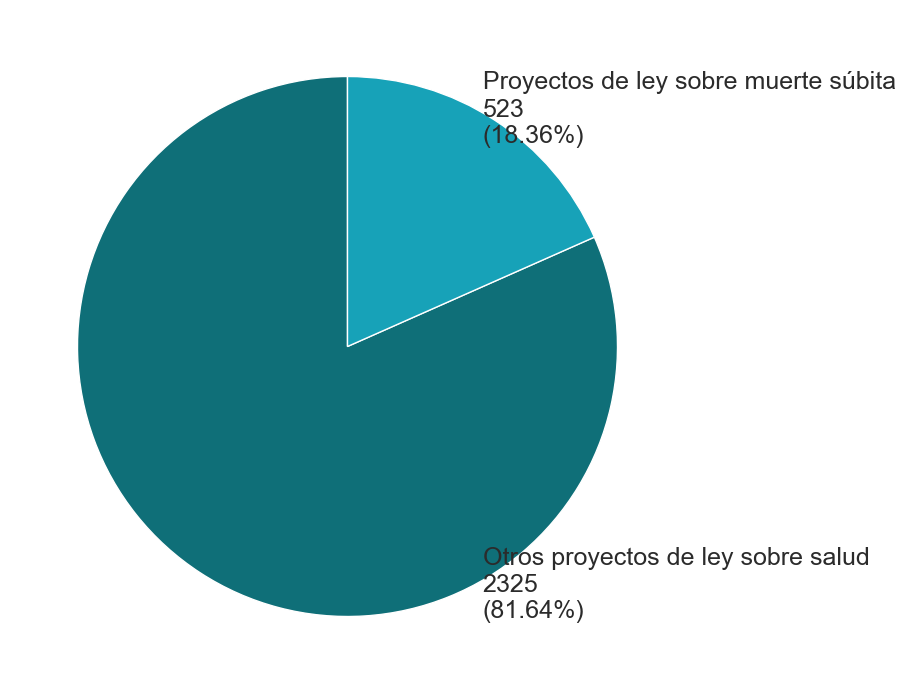

<Figure size 800x500 with 0 Axes>

In [18]:
# --- GRÁFICO 1: TORTA - TOTAL PROYECTOS VS SALUD ---
labels_pie1 = ['Otros proyectos de ley sobre salud', 'Proyectos de ley sobre muerte súbita']
sizes_pie1 = [total_no_mssalud1, total_ms1]

# Paleta de colores accesible para daltonismo (protanopia, deuteranopia)
# Colores con alto contraste y diferenciables para la mayoría de tipos de daltonismo

colors_pie1 = ['#0F6F78', '#17A2B8'] # GRAY_MAIN 

# Dirección para guarda gráfica
figfile = BASE_DIR+'imagenes/proyectosSaludotrovsms_accesible.png'

# Crear gráfica
plot_torta_salud(labels_pie1,sizes_pie1,colors_pie1,figfile)

se identificaron 20 términos, de los cuales se identifican como especificos 6 términos: 
 'muerte_subita',
 'desfibrilador',
 'desfibracion',
 'dea',
 'reanimacion',
 'cardiovascular'. 

528 proyectos de ley sobre salud se relacionan con muerte subita segúnn los 20 terminos seleccionados.
Si se consideran los términos especificos, son 80 proyectos de ley sobre salud relacionados con muerte (2,8%)
 

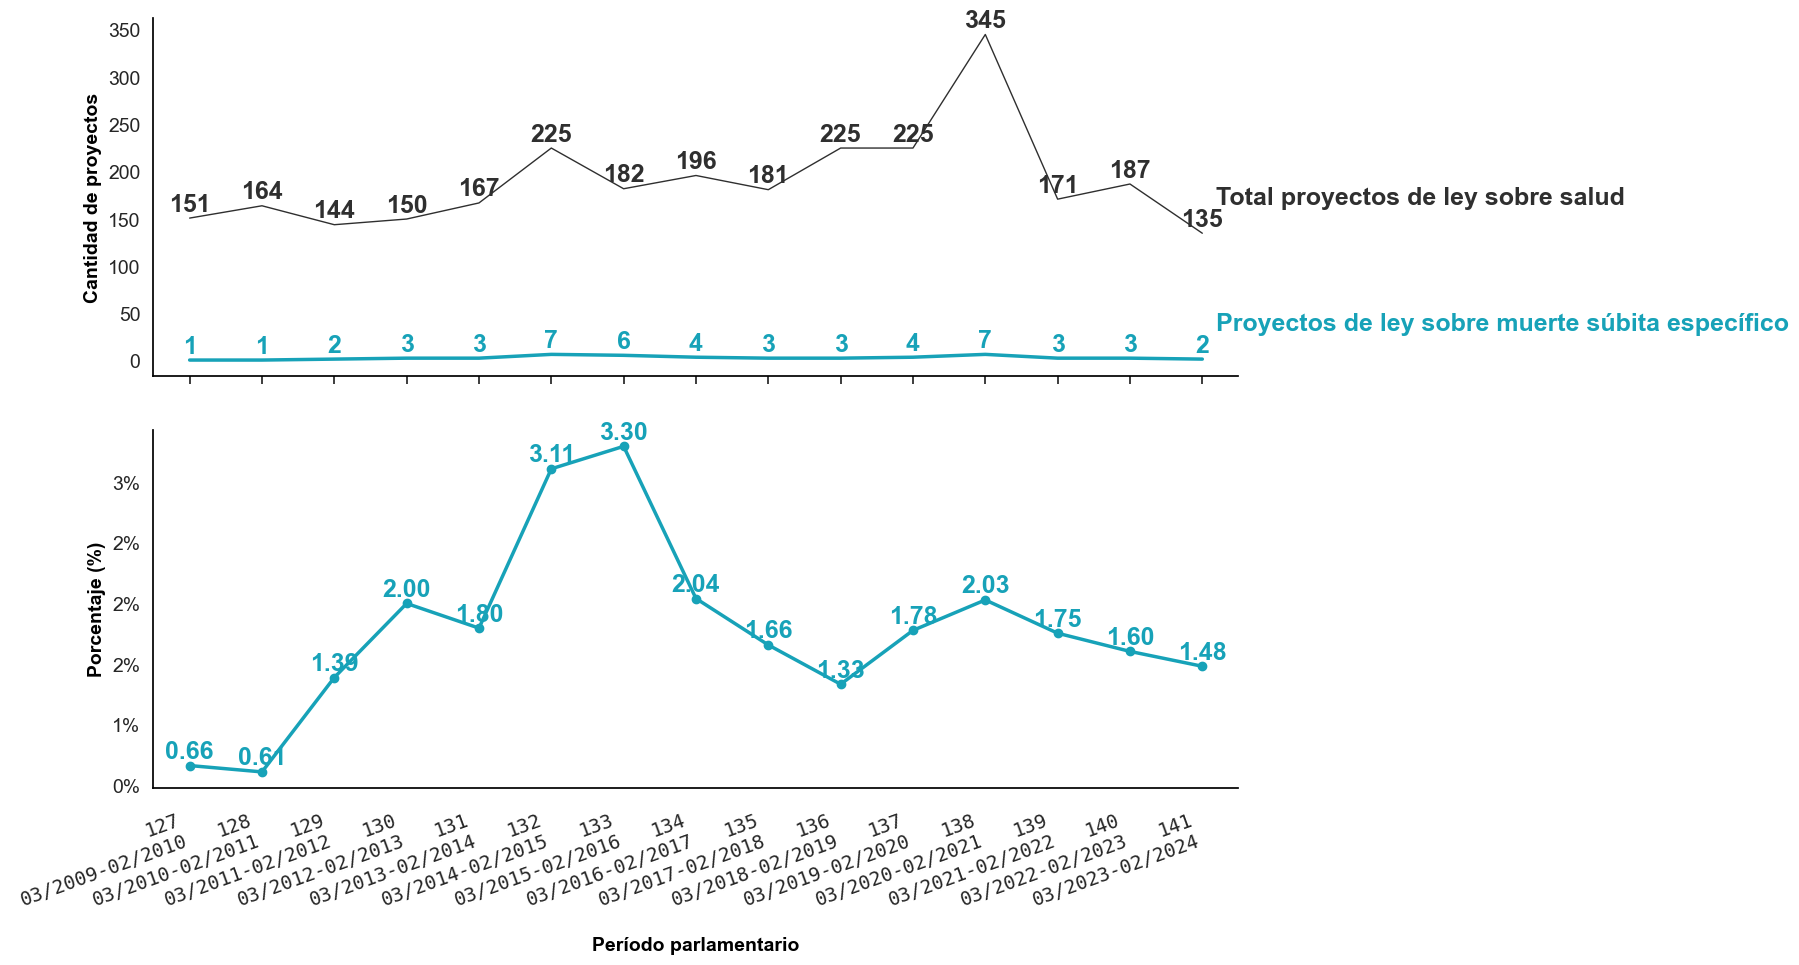

In [19]:
# Configurar el estilo y crear la grilla
from matplotlib.ticker import PercentFormatter
from matplotlib.ticker import PercentFormatter

period_dict = {
        127: '03/2009-02/2010',
        128: '03/2010-02/2011',
        129: '03/2011-02/2012',
        130: '03/2012-02/2013',
        131: '03/2013-02/2014',
        132: '03/2014-02/2015',
        133: '03/2015-02/2016',
        134: '03/2016-02/2017',
        135: '03/2017-02/2018',
        136: '03/2018-02/2019',
        137: '03/2019-02/2020', 
        138: '03/2020-02/2021', 
        139: '03/2021-02/2022',
        140: '03/2022-02/2023',
        141: '03/2023-02/2024',
    }

def periodos_a_fechas(periodo):
    
    if periodo in period_dict:
        return f'{periodo}\n{period_dict[periodo]}'
    return ''

def label_line_end(ax, x, y, label, color, offset=(5, 0)):
    return ax.annotate(
        label,
        xy=(x, y),
        xytext=offset,
        textcoords='offset points',
        color=color,
        fontsize=18,
        fontweight='bold',
        va='center'
    )


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
# Colores accesibles (contraste adecuado y distinguibles para daltónicos)


colors = {
    'proyectos_salud': '#2F2F2F',#GRAY_LIGHT,
    'proyectos_ms_esp': '#17A2B8', #HEALTH_CYAN, 
    'proyectos_ms_noesp': GRAY_MAIN, #'#17A2B8', 
    'pct_msE': '#17A2B8' ,#HEALTH_CYAN,        
    'pct_msNE': GRAY_MAIN,    
    'grid': '#cccccc',
    'text': 'black'
}

offset= (6, 0)
RED_HEALTH   = "#7A2E2E"
GREEN_HEALTH = "#8FBFA8"


# --- GRÁFICO 1: LÍNEA - TENDENCIA ANUAL (FRECUENCIA ABSOLUTA) ---
line_total = ax1.plot(summary1_df['Periodo'], summary1_df['proyectos_salud'], 
         marker='', linewidth=1, label='Total proyectos de ley sobre salud',
         color=colors['proyectos_salud'])

#line_salud_noesp = ax1.plot(summary1_df['Periodo'], summary1_df['proyectos_no_saludmsesp'], 
#         marker='', linewidth=2.5, label='Proyectos de ley sobre muerte súbita no especifico',
#         color=colors['proyectos_ms_noesp'])

line_salud_esp = ax1.plot(summary1_df['Periodo'], summary1_df['proyectos_ms_esp'], 
         marker='', linewidth=2.5, label='Proyectos de ley sobre muerte súbita específico',
         color=colors['proyectos_ms_esp'])


ax1.set_ylabel('Cantidad de proyectos', fontsize=14, fontweight='bold', color=colors['text'])
#ax1.set_title('Distribución de proyectos por período parlamentario', fontweight='bold', fontsize=14, pad=20)
#ax1.legend(loc='upper right', framealpha=0.9)
ax1.tick_params(axis='x', which='both', bottom=True, labelbottom=False)  # Ocultar labels del x-axis superior
ax1.tick_params(axis='y', labelsize=14)
ax1.tick_params(axis='x', labelsize=14)

# Añadir valores en los puntos
for i, (periodo, total, saludNE, saludE) in enumerate(zip(summary1_df['Periodo'], 
                                              summary1_df['proyectos_salud'],
                                              summary1_df['proyectos_no_saludmsesp'],
                                              summary1_df['proyectos_ms_esp'])):

    
        ax1.annotate(locale.format_string('%d', int(saludE), grouping=True), 
                     xy=(periodo, saludE),
                     xytext=(0, 5), textcoords='offset points',  
                     ha='center', fontsize=18, fontweight='bold',
                     color=colors['proyectos_ms_esp'])
      #  ax1.annotate(locale.format_string('%d', int(saludNE), grouping=True), 
      #               xy=(periodo, saludNE),
      #               xytext=(0, 5), textcoords='offset points',  
      #               ha='center', fontsize=18, fontweight='bold',
      #               color=colors['proyectos_ms_noesp'])
        ax1.annotate(locale.format_string('%d', int(total), grouping=True), 
                     xy=(periodo, total),
                     xytext=(0, 5), textcoords='offset points',  
                     ha='center', fontsize=18, fontweight='bold',
                     color=colors['proyectos_salud'])

    

#	Periodo 	total_proyectos 	proyectos_salud 	proyectos_ms 	pct_salud 	proyectos_nosalud 	proyectos_no_saludms

#label_line_end(ax1, summary1_df['Periodo'].iloc[-1], summary1_df['proyectos_no_saludmsesp'].iloc[-1],
#           'Proyectos de ley sobre muerte súbita no especifico', colors['proyectos_ms_noesp'],offset=(10, 25))

label_line_end(ax1, summary1_df['Periodo'].iloc[-1], summary1_df['proyectos_ms_esp'].iloc[-1],
           'Proyectos de ley sobre muerte súbita específico', colors['proyectos_ms_esp'],offset=(10, 25))
    
label_line_end(ax1, summary1_df['Periodo'].iloc[-1], summary1_df['proyectos_salud'].iloc[-1],
           'Total proyectos de ley sobre salud', colors['proyectos_salud'],offset=(10, 25))


# --- GRÁFICO 2: LÍNEA - TENDENCIA ANUAL (FRECUENCIA RELATIVA) ---
#ax2.plot(summary1_df['Periodo'], summary1_df['pct_msNE'],  # Convertir a porcentaje
#         marker='o', linewidth=2.5, color=colors['pct_msNE'], 
#         label='% Proyectos de ley sobre muerte súbita no especifico', markersize=6)


ax2.plot(summary1_df['Periodo'], summary1_df['pct_msE'],  # Convertir a porcentaje
         marker='o', linewidth=2.5, color=colors['pct_msE'], 
         label='% Proyectos de ley sobre muerte súbita especifico', markersize=6)

ax2.set_xlabel('Período parlamentario', fontsize=14, fontweight='bold', color=colors['text'])
ax2.set_ylabel('Porcentaje (%)', fontsize=14, fontweight='bold', color=colors['text'])
    
#label_line_end(ax2, summary1_df['Periodo'].iloc[-1], summary1_df['pct_salud'].iloc[-1],
#           '% Proyectos sobre salud', colors['pct_salud'],offset=(10, 25))

#ax2.legend(loc='upper right', framealpha=0.9, ncols = 2)
#ax2.grid(True, alpha=0.4, color=colors['grid'])
#ax2.yaxis.set_major_formatter(PercentFormatter(decimals=0))

# Configurar los ticks del eje X con las fechas
xticks = sorted(summary1_df['Periodo'].unique())
xtick_labels = [periodos_a_fechas(x) for x in xticks]
ax2.tick_params(axis='y', labelsize=14)
ax2.tick_params(axis='x', labelsize=14)


ax2.set_xticks(xticks)
ax2.set_xticklabels(xtick_labels, 
                   rotation=20, 
                   ha='right', 
                   fontsize=14,           # Tamaño de fuente más grande
                   family='monospace')    # Fuente monoespaciada para mejor alineación

# Ajustar los márgenes para que las etiquetas no se corten
ax2.tick_params(axis='x', which='major', pad=10)  # Más espacio entre labels y eje

# Añadir fondo alternado para mejor lectura
ax2.set_axisbelow(True)
for i, periodo in enumerate(xticks):
    if i % 2 == 0:  # Fondos alternados
        ax2.axvspan(periodo - 0.4, periodo + 0.4, alpha=0.05, color='white')

# Ajustar los límites del eje X para mejor visualización
ax2.set_xlim(xticks[0] - 0.5, xticks[-1] + 0.5)

# Añadir título descriptivo al eje X
ax2.set_xlabel('Período parlamentario', 
              fontsize=14, 
              fontweight='bold', 
              labelpad=20)

# Añadir valores de porcentaje
for i, (periodo, pctE, pctNE) in enumerate(zip(summary1_df['Periodo'], summary1_df['pct_msE'],summary1_df['pct_msNE'])):
    ax2.annotate(f"{locale.format_string('%.2f', pctE)}",
                 xy=(periodo, pctE),
                 xytext=(0, 5), textcoords='offset points', 
                 ha='center', fontsize=18, fontweight='bold',
                 color=colors['pct_msE'])
    #ax2.annotate(f"{locale.format_string('%.2f', pctNE)}",
    #             xy=(periodo, pctNE),
    #             xytext=(0, 5), textcoords='offset points', 
    #             ha='center', fontsize=18, fontweight='bold',
     #            color=colors['pct_msNE'])
  



for ax in [ax1, ax2]:
    # Quitar cualquier grilla activa
    ax.grid(False)

    # Ocultar bordes superior y derecho
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Mantener solo los ejes izquierdo e inferior en negro
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_color('black')


ax2.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))

ax1.set_facecolor('white')
ax2.set_facecolor('white')




# Guardar en alta calidad para accesibilidad
plt.savefig(BASE_DIR+'imagenes/evolucion_proyectosMS.png', 
            dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')

# Ajustar el espacio entre subplots
plt.subplots_adjust(hspace=0.15)
# --- AJUSTES FINALES ---
#plt.tight_layout(pad=2)
#plt.subplots_adjust(hspace=0.1, bottom=0.25)  # Ajustar espacio inferior
plt.show()

El análisis exploratorio de la base de datos de proyectos legislativos evidenció un incremento excepcional en la cantidad de iniciativas vinculadas a la salud durante el período parlamentario 138 (03/2020–02/2021), seguido por el período 139 (03/2021–02/2022). Este aumento se corresponde con el contexto sanitario global generado por la pandemia de COVID-19, que motivó una mayor actividad legislativa en materia de salud pública.

Al focalizar el análisis en los proyectos de ley sobre salud vinculados a muerte súbita, distinguiendo entre términos específicos y no específicos, se observa que la mayor proporción de proyectos con términos específicos se registra en el período parlamentario 133 (03/2015–02/2016), mientras que la menor proporción se identifica en el período 128 (03/2010–02/2011).

El incremento de proyectos específicos durante el período parlamentario 135 podría asociarse al proceso de implementación institucional de la Ley 27.159, sancionada en Julio del 2015 en Argentina. 



En contraste, los proyectos asociados a términos no específicos presentan un patrón diferente, caracterizado por la presencia de varios picos. El máximo se observa en el período parlamentario 127 (03/2009–02/2010), mientras que el mínimo se registra en el período 132 (03/2014–02/2015).

El pico registrado en el período 127 coincide con un evento sanitario de gran relevancia en Argentina: la pandemia de Influenza A (H1N1). El 11 de junio de 2009, la Organización Mundial de la Salud declaró el estado de pandemia ante la rápida propagación global del nuevo virus. En ese contexto, es plausible que se hayan presentado numerosos proyectos legislativos vinculados con emergencias sanitarias, prevención y fortalecimiento de la respuesta del sistema de salud, los cuales suelen incluir términos generales como prevención, emergencia, capacitación o supervivencia, coincidentes con los términos utilizados para la identificación de proyectos no específicos en este estudio.

Por su parte, el mínimo observado en el período parlamentario 132 podría vincularse con el contexto político e institucional previo al año electoral presidencial de 2015, período en el cual la agenda legislativa suele concentrarse en debates de mayor centralidad política, reduciendo la presentación de iniciativas sectoriales en áreas específicas como la salud.VER PAPER


In [20]:
summary1_df

,Periodo,total_proyectos,proyectos_salud,proyectos_ms,proyectos_ms_esp,pct_salud,pct_ms,pct_msE,proyectos_nosalud,proyectos_no_saludms,proyectos_no_saludmsesp,pct_msNE
0,127,1721,151.0,40,1,8.773969,26.490066,0.662252,1570.0,111.0,39,25.827815
1,128,2239,164.0,23,1,7.324699,14.024390,0.609756,2075.0,141.0,22,13.414634
2,129,1541,144.0,32,2,9.344581,22.222222,1.388889,1397.0,112.0,30,20.833333
3,130,2164,150.0,23,3,6.931608,15.333333,2.000000,2014.0,127.0,20,13.333333
4,131,1873,167.0,30,3,8.916177,17.964072,1.796407,1706.0,137.0,27,16.167665
5,132,3001,225.0,32,7,7.497501,14.222222,3.111111,2776.0,193.0,25,11.111111
6,133,1996,182.0,47,6,9.118236,25.824176,3.296703,1814.0,135.0,41,22.527473
7,134,2763,196.0,27,4,7.093739,13.775510,2.040816,2567.0,169.0,23,11.734694
8,135,2437,181.0,28,3,7.427165,15.469613,1.657459,2256.0,153.0,25,13.812155
9,136,2805,225.0,32,3,8.021390,14.222222,1.333333,2580.0,193.0,29,12.888889


In [21]:
summary1_df['proyectos_salud'].sum()

2848.0

### ¿Los proyectos sobre muerte súbita siguen el mismo circuito institucional que el resto de proyectos de salud o tienen una trayectoria diferenciada?

###  ¿El tratamiento parlamentario de los proyectos de salud tiende a ser más corto o más extendido?
##### Distribución relativa Distribución de la cantidad de giros entre tipos de proyectos.:¿Qué porcentaje de proyectos de salud aparece en cada Max_Orden?
¿Los proyectos de salud atraviesan trayectorias legislativas con más o menos giros a comisión que los proyectos de otros temas?


Cuántas veces el proyecto fue enviado a comisión en su trayectoria parlamentaria.

Esto puede reflejar:

* reenvíos

* ampliación del tratamiento

+ nuevas intervenciones institucionales

* prolongación del trámite legislativo

In [22]:
# ley_df["Max_Orden"].value_counts()
# check  2:  15139
13611 + 1528

15139

In [23]:
salud_df = ley_df[ley_df["Proyecto_SALUD"] == 1]
print('Control proyectos de salud:', salud_df.shape)
#no_salud = ley_df[ley_df["Proyecto_SALUD"] == 0]["Max_Orden"].dropna()

Control proyectos de salud: (2848, 42)


In [24]:
etiq1 = "Proyecto de ley sobre salud" 
etiq2 = 'Otros proyectos de ley'

ley_df["tipo_salud"] = ley_df["Proyecto_SALUD"].map({1: etiq1, 0: etiq2})

In [25]:
salud_df = ley_df[ley_df['Proyecto_SALUD']==1].copy()
etiq3 = "Proyecto de ley sobre muerte súbita específico" 
etiq4 = "Otros proyectos de ley sobre salud "
salud_df["tipo_ms"] = salud_df["Proyecto_MS_especifico"].map({1: etiq3, 0: etiq4})
salud_df.shape

(2848, 44)

In [26]:
salud_df["Proyecto_MS_especifico"].sum()

52

In [27]:
salud_df["Proyecto_MS_especifico"].value_counts()

Proyecto_MS_especifico
0    2796
1      52
Name: count, dtype: int64

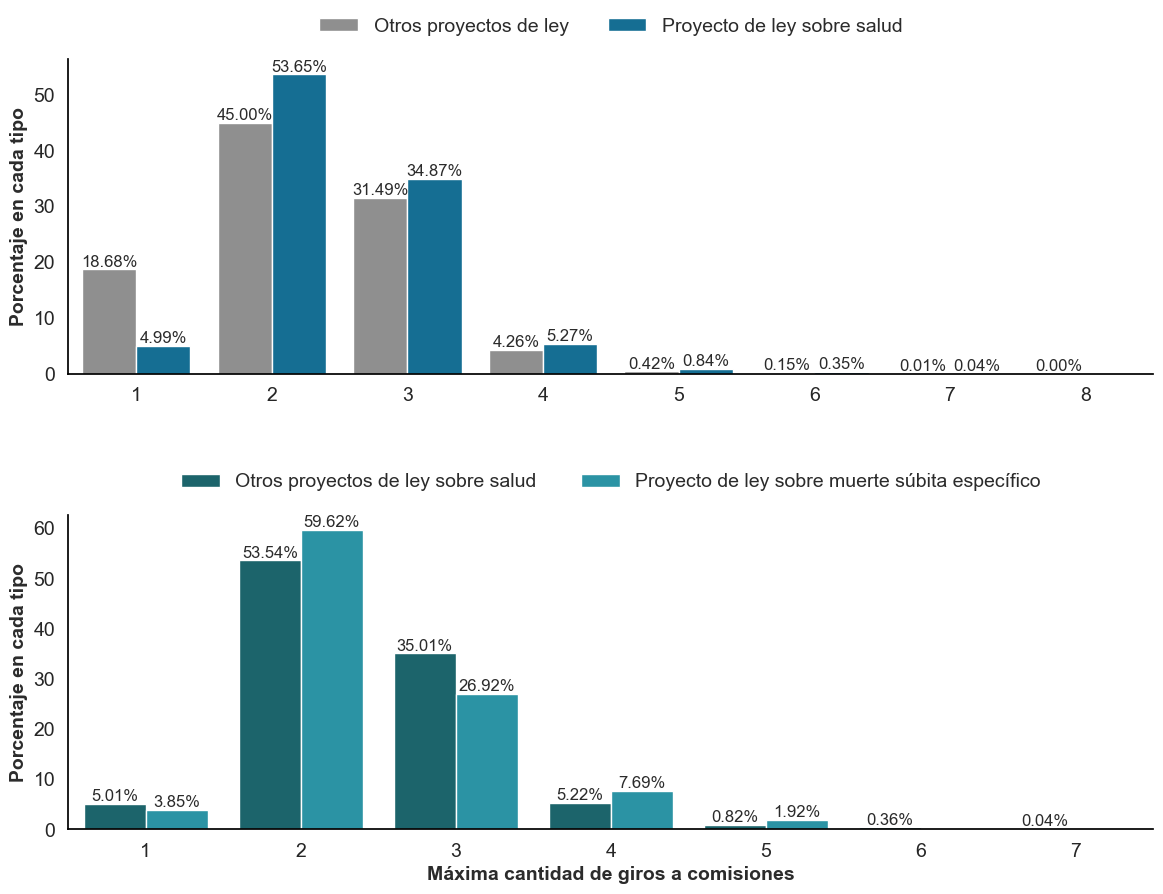

In [28]:
PALETA = {  
    etiq1: HEALTH_CYAN,
    etiq2: GRAY_MAIN
}

PALETA2 = {  
    etiq3: '#17A2B8',
    etiq4: '#0F6F78', #'#3A6EA5', #GRAY_DARK #GRAY_MAIN
}



df_pct = (
    ley_df
    .groupby(["Proyecto_SALUD", "Max_Orden"])
    .size()
    .rename("n")
    .reset_index()
)

df_pct["porcentaje"] = (
    df_pct["n"] /
    df_pct.groupby("Proyecto_SALUD")["n"].transform("sum")
) * 100

df_pct["tipo"] = df_pct["Proyecto_SALUD"].map({1:etiq1, 0:etiq2})

df_pct2 = (
    salud_df
    .groupby(["Proyecto_MS_especifico", "Max_Orden"])
    .size()
    .rename("n")
    .reset_index()
)

df_pct2["porcentaje"] = (
    df_pct2["n"] /
    df_pct2.groupby("Proyecto_MS_especifico")["n"].transform("sum")
) * 100

df_pct2["tipo"] = df_pct2["Proyecto_MS_especifico"].map({1:etiq3, 0:etiq4})

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=False)
sns.barplot(
    data=df_pct,
    x="Max_Orden",
    y="porcentaje",
    hue="tipo",
    palette=PALETA,
    ax = ax1
)

sns.barplot(
    data=df_pct2,
    x="Max_Orden",
    y="porcentaje",
    hue="tipo",
    palette=PALETA2,
    ax = ax2
)




# Agregar etiquetas a cada barra
for p in ax1.patches:
    height = p.get_height()
    
    if height > 0:
        ax1.annotate(
            f"{locale.format_string('%.2f', height)}%",
            (p.get_x() + p.get_width()/2, height),
            ha="center",
            va="bottom",
            fontsize=12
        )

# Agregar etiquetas a cada barra
for p in ax2.patches:
    height = p.get_height()
    
    if height > 0:
        ax2.annotate(
            f"{locale.format_string('%.2f', height)}%",
            (p.get_x() + p.get_width()/2, height),
            ha="center",
            va="bottom",
            fontsize=12
        )

ax1.set_ylabel('Porcentaje en cada tipo', fontsize=14, fontweight='bold')
ax2.set_ylabel('Porcentaje en cada tipo', fontsize=14, fontweight='bold')
ax1.set_xlabel('', fontsize=14, fontweight='bold')
ax2.set_xlabel('Máxima cantidad de giros a comisiones', fontsize=14, fontweight='bold')



#ax1.legend(loc='upper right', framealpha=0.9)
ax1.tick_params(axis='y', labelsize=14)
ax1.tick_params(axis='x', labelsize=14)
ax2.tick_params(axis='y', labelsize=14)
ax2.tick_params(axis='x', labelsize=14)

for ax in [ax1,ax2]:
    # Quitar cualquier grilla activa
    ax.grid(False)

    # Ocultar bordes superior y derecho
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Mantener solo los ejes izquierdo e inferior en negro
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_color('black')



ax1.set_facecolor('white')
ax2.set_facecolor('white')


ax1.legend(
    title="",
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    frameon=False,
    fontsize=14
)

ax2.legend(
    title="",
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    frameon=False,
    fontsize=14
)

# Guardar en alta calidad para accesibilidad
plt.savefig(BASE_DIR+'imagenes/maxgiro_ms.png', 
            dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')

plt.subplots_adjust(hspace=0.45)
plt.show()

In [29]:
ley_df.groupby("Proyecto_SALUD")["Max_Orden"].median()

Proyecto_SALUD
0.0    2.0
1.0    2.0
Name: Max_Orden, dtype: float64

Tanto los proyectos de ley sobre  salud como los de otros proyectos de ley presentan una mediana de dos giros a comisión, lo que indica que el tratamiento legislativo típico involucra al menos dos instancias de giro a comisión.
De la figura se observa que Los proyectos de ley sobre salud rara vez tienen un solo giro a comisión (4.99%). Más de la mitad de los proyectos de ley sobre salud tienen exactamente dos giros a comisión, mientras que en el resto de los proyectos esto ocurre en el 45%. Por otra parte los proyectos de ley sobre salud (6.50%) tienen ligeramente más proyectos con múltiples giros (max_orden +4) que otros proyectos de ley (5.83%).

In [30]:
df_pct

,Proyecto_SALUD,Max_Orden,n,porcentaje,tipo
0,0.0,1,5650,18.678303,Otros proyectos de ley
1,0.0,2,13611,44.996529,Otros proyectos de ley
2,0.0,3,9525,31.488644,Otros proyectos de ley
3,0.0,4,1288,4.257992,Otros proyectos de ley
4,0.0,5,126,0.416543,Otros proyectos de ley
5,0.0,6,44,0.145459,Otros proyectos de ley
6,0.0,7,4,0.013224,Otros proyectos de ley
7,0.0,8,1,0.003306,Otros proyectos de ley
8,1.0,1,142,4.985955,Proyecto de ley sobre salud
9,1.0,2,1528,53.651685,Proyecto de ley sobre salud


In [31]:
salud_df.groupby("Proyecto_MS_especifico")["Max_Orden"].median()

Proyecto_MS_especifico
0    2.0
1    2.0
Name: Max_Orden, dtype: float64

In [32]:
df_pct2


,Proyecto_MS_especifico,Max_Orden,n,porcentaje,tipo
0,0,1,140,5.007153,Otros proyectos de ley sobre salud
1,0,2,1497,53.540773,Otros proyectos de ley sobre salud
2,0,3,979,35.014306,Otros proyectos de ley sobre salud
3,0,4,146,5.221745,Otros proyectos de ley sobre salud
4,0,5,23,0.822604,Otros proyectos de ley sobre salud
5,0,6,10,0.357654,Otros proyectos de ley sobre salud
6,0,7,1,0.035765,Otros proyectos de ley sobre salud
7,1,1,2,3.846154,Proyecto de ley sobre muerte súbita específico
8,1,2,31,59.615385,Proyecto de ley sobre muerte súbita específico
9,1,3,14,26.923077,Proyecto de ley sobre muerte súbita específico


Lo primero importante es el tamaño de la muestra:

Salud – otros temas: 2796 proyectos

Muerte súbita específica: 52 proyectos

Esto significa que cualquier diferencia debe interpretarse con cautela, pero aun así se pueden observar algunos patrones interesantes.

El patrón general es muy parecido:

la mayoría se concentra en 2 o 3 giros

muy pocos tienen 1 giro

muy pocos superan 4 giros

La distribución del número de giros a comisión de los proyectos de ley sobre muerte súbita presenta un patrón similar al observado en el resto de las iniciativas legislativas en salud. Sin embargo, estos proyectos muestran una mayor concentración en esquemas de doble giro a comisión, lo que sugiere un tratamiento parlamentario relativamente estandarizado en comparación con otras iniciativas sanitarias.

* ¿El número de giros a comisión difiere entre proyectos de salud y no salud?

In [33]:
from scipy.stats import mannwhitneyu

salud = ley_df[ley_df["Proyecto_SALUD"]==1]["Max_Orden"]
no_salud = ley_df[ley_df["Proyecto_SALUD"]==0]["Max_Orden"]

stat, p = mannwhitneyu(salud, no_salud, alternative="two-sided")

print(stat, p)

48758743.5 5.4417431462195135e-36


p < 0.05 → diferencia significativa

In [34]:

salud_df = ley_df[ley_df["Proyecto_SALUD"]==1].copy()
ms = salud_df[salud_df["Proyecto_MS_especifico"]==1]["Max_Orden"]
no_ms = salud_df[salud_df["Proyecto_MS_especifico"]==0]["Max_Orden"]
stat, p = mannwhitneyu(ms, no_ms, alternative="two-sided")

print(stat, p)

70984.0 0.7451044617039815


No se observaron diferencias estadísticamente significativas...

### ¿Qué comisiones dominan la agenda de salud?

Dado que la clasificación inicial de los proyectos de salud se realizó parcialmente a partir de la identificación de comisiones vinculadas al área sanitaria, dichas comisiones fueron excluidas del análisis comparativo de distribución institucional.
Analizando la variable comision_nombre_normalizada_Levenshtein, que representa el nombre de la comision legislativa a las que se gira un proyecto se plantea  la pregunta: ¿Los proyectos de ley de salud y otros de ley se distribuyen de manera diferente entre las comisiones legislativas?
 ¿Los proyectos de ley de salud sobre muerte súbita especifica y otros de ley de salud se distribuyen de manera diferente entre las comisiones legislativas?


In [35]:
with open(RESULTADOS_DIR +'ley_com_df.pkl', 'rb') as file: ## Para tener los textos procesados
    ley_com_df = pickle.load(file)
print(ley_com_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74175 entries, 0 to 74174
Data columns (total 42 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Proyecto.ID                              74175 non-null  object        
 1   Título                                   74175 non-null  category      
 2   Publicación.Fecha                        74175 non-null  datetime64[ns]
 3   Publicación.ID                           74175 non-null  category      
 4   Exp..Diputados                           74175 non-null  category      
 5   Tipo                                     74175 non-null  category      
 6   Max_Orden                                74175 non-null  int64         
 7   Proyecto_girado_a_comisiones_SALUD       74175 non-null  float64       
 8   Proyecto_SALUD                           74175 non-null  float64       
 9   Resultado                              

In [36]:
ley_com_df.describe(include = 'all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Proyecto.ID,74175,33097,HCDN125189,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Título,74175,31392,JUICIO POR JURADOS. CREACION.,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Publicación.Fecha,74175,NaN,NaN,NaN,2016-06-05 07:50:01.286147584,2009-03-02 00:00:00,2013-03-08 00:00:00,2016-06-08 00:00:00,2019-09-24 00:00:00,2024-02-29 00:00:00,NaN
Publicación.ID,74175,2934,HCDN134TP001,272,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Exp..Diputados,74175,33097,0576-D-2011,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tipo,74175,1,LEY,74175,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Max_Orden,74175.0,NaN,NaN,NaN,2.543701,1.0,2.0,3.0,3.0,8.0,0.81685
Proyecto_girado_a_comisiones_SALUD,74175.0,NaN,NaN,NaN,0.147004,0.0,0.0,0.0,0.0,1.0,0.354112
Proyecto_SALUD,74175.0,NaN,NaN,NaN,0.093509,0.0,0.0,0.0,0.0,1.0,0.291146
Resultado,74175,6,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN,71406,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
# Comisiones ordenadas por % de intervenciones en proyectos sobre salud
ley_com_df['comision_nombre_normalizada_Levenshtein'].value_counts( normalize=True)#.head((10)

comision_nombre_normalizada_Levenshtein
presupuesto y hacienda                                                    0.239488
legislacion general                                                       0.084435
accion social y salud publica                                             0.057000
legislacion del trabajo                                                   0.054776
legislacion penal                                                         0.049680
                                                                            ...   
sobre tablas                                                              0.000054
juicio politico                                                           0.000054
economias regionales micro pequena y mediana empresa                      0.000054
bicameral de los derechos de las ninas ninos y adolescentes ley numero    0.000013
bicameral de la defensoria del pueblo                                     0.000013
Name: proportion, Length: 72, dtype: float64

In [38]:
#Control len(ley_com_df[ley_com_df['Proyecto_MS']==1]['Proyecto.ID'].unique())

In [39]:
ley_com_df["Proyecto_MSE"] = 0
ley_com_df.loc[(ley_com_df['Proyecto.ID'].isin(list(ms_estricto_df['Proyecto.ID'].values)) & (ley_com_df['Proyecto_MS']==1) ), 'Proyecto_MSE'] = 1

In [40]:
#Control 
len(ley_com_df[ley_com_df['Proyecto_MSE']==1]['Proyecto.ID'].unique())

52

In [41]:
salud_com = ['accion social y salud publica','asistencia social y salud publica','salud','salud y deporte']
ley_com_df2 = ley_com_df[~ley_com_df['comision_nombre_normalizada_Levenshtein'].isin(salud_com)].copy()

¿Las iniciativas de salud se concentran en determinadas comisiones del Congreso?

In [42]:
# --- Ejecutar reportes ---

df_all = ley_com_df2.copy()
df_nosalud = df_all[df_all["Proyecto_SALUD"] == 0]
df_salud = df_all[df_all["Proyecto_SALUD"] == 1]
df_nomse = df_all[df_all["Proyecto_MSE"] == 0]
df_mse = df_all[df_all["Proyecto_MSE"] == 1]

In [43]:
print(len(df_mse['Proyecto.ID'].unique()),df_mse.info())


<class 'pandas.core.frame.DataFrame'>
Index: 72 entries, 2028 to 70485
Data columns (total 43 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Proyecto.ID                              72 non-null     object        
 1   Título                                   72 non-null     category      
 2   Publicación.Fecha                        72 non-null     datetime64[ns]
 3   Publicación.ID                           72 non-null     category      
 4   Exp..Diputados                           72 non-null     category      
 5   Tipo                                     72 non-null     category      
 6   Max_Orden                                72 non-null     int64         
 7   Proyecto_girado_a_comisiones_SALUD       72 non-null     float64       
 8   Proyecto_SALUD                           72 non-null     float64       
 9   Resultado                                72 

In [44]:

def comisiones_stats(subset, name, k=10):
    total = len(subset)

    # Frecuencia absoluta por comisión
    freq_abs = (
        subset.groupby("comision_nombre_normalizada_Levenshtein")
              .size()
              .sort_values(ascending=False)
    )

    # Frecuencia relativa (%)
    freq_rel = ((freq_abs / total) * 100).round(2)

    print(f"\n===== {name} =====")
    print(f"N proyectos: {total}\n")

    print("📌 Top "+str(k)+"comisiones (Frecuencia absoluta):")
    print(freq_abs.head(k), "\n")
    
    print("📌 Top "+str(k)+" comisiones (Frecuencia relativa %):")
    print(freq_rel.head(k))
    
    return freq_abs, freq_rel



In [45]:

com_all_abs, com_all_rel = comisiones_stats(df_all, "TODOS los Proyectos")
df = pd.concat([com_all_abs, com_all_rel], axis=1).reset_index()
df.columns = ['Comisión legislativa',  'frec', '%']
top10_df = df.copy()

com_salud_abs, com_salud_rel = comisiones_stats(df_salud, "Proyectos de ley sobre salud")
com_nosalud_abs, com_nosalud_rel = comisiones_stats(df_nosalud, "Otros proyectos de ley")
df = pd.concat([com_salud_abs, com_salud_rel], axis=1).reset_index()
df.columns = ['Comisión legislativa',  'frec', '%']
top10_df = pd.merge(top10_df, df, left_index=True, right_index=True)


com_mse_abs, com_mse_rel = comisiones_stats(df_mse, "Proyecto de ley sobre muerte subíta específica")
com_nomse_abs, com_nomse_rel = comisiones_stats(df_nomse, "Otros proyectos de ley sobre salud")
df = pd.concat([com_mse_abs, com_mse_rel], axis=1).reset_index()
df.columns = ['Comisión legislativa',  'frec', '%']
top10_df = pd.merge(top10_df, df, left_index=True, right_index=True)



===== TODOS los Proyectos =====
N proyectos: 69831

📌 Top 10comisiones (Frecuencia absoluta):
comision_nombre_normalizada_Levenshtein
presupuesto y hacienda                17764
legislacion general                    6263
legislacion del trabajo                4063
legislacion penal                      3685
asuntos constitucionales               2983
justicia                               2547
educacion                              2367
familia mujer ninez y adolescencia     2270
cultura                                1685
transportes                            1673
dtype: int64 

📌 Top 10 comisiones (Frecuencia relativa %):
comision_nombre_normalizada_Levenshtein
presupuesto y hacienda                25.44
legislacion general                    8.97
legislacion del trabajo                5.82
legislacion penal                      5.28
asuntos constitucionales               4.27
justicia                               3.65
educacion                              3.39
familia mujer nin

In [46]:
top10_df


,Comisión legislativa_x,frec_x,%_x,Comisión legislativa_y,frec_y,%_y,Comisión legislativa,frec,%
0,presupuesto y hacienda,17764,25.44,presupuesto y hacienda,1882,46.96,presupuesto y hacienda,44,61.11
1,legislacion general,6263,8.97,legislacion general,375,9.36,educacion,11,15.28
2,legislacion del trabajo,4063,5.82,familia mujer ninez y adolescencia,216,5.39,deportes,3,4.17
3,legislacion penal,3685,5.28,educacion,165,4.12,legislacion general,3,4.17
4,asuntos constitucionales,2983,4.27,comercio,153,3.82,discapacidad,2,2.78
5,justicia,2547,3.65,legislacion del trabajo,142,3.54,familia mujer ninez y adolescencia,2,2.78
6,educacion,2367,3.39,industria,140,3.49,familias ninez y juventudes,2,2.78
7,familia mujer ninez y adolescencia,2270,3.25,discapacidad,122,3.04,transportes,2,2.78
8,cultura,1685,2.41,prevencion de adicciones y control del narcotrafico,105,2.62,banca de la mujer,1,1.39
9,transportes,1673,2.40,comunicaciones e informatica,97,2.42,comunicaciones e informatica,1,1.39


Las comisiones son espacios de analisis y debate sobre los proyectos conformadas por legisladores de distintos bloques. Hay 46 comisiones permanentes, que son centrales en las discusiones parlamentarias. Existen tambien 32 comisiones especiales, que tratan temas especificos, en general bicamerales, que estan formados por diputados y senadores. (Para citar https://www.youtube.com/watch?v=dYtTj-NkMO0&t=2s)
Por el artículo 122 del reglamento de la camara de diputados,  es el presidente de la camara quien decide a cuantas comisiones el proyecto de ley debe ser girado.

* Artículo 122. Cuando el Poder Ejecutivo presentare algún proyecto, será anunciado y pasará sin más trámite a la comisión respectiva. Lo mismo se observara con las senaciones procedentes del senado. (Para citar https://www.hcdn.gob.ar/institucional/reglamento/index.html)


Si se analiza los top 10 comisiones de proyecto de ley, los top 10 de proyecto de ley de salud y los top 10 de proyecto de ley sobre muerte subita especifico ,se observa:
* los proyecto de ley son girados mayoritariamente, según top 1 sin distincion de  tipos de proyectos explorados a la comision permanente de 'presupuesto y hacienda' (proyecto de ley: 25,44% , salud:46,96%, proyecto de muerte subita: 61,11%). Está comisión tiene la  competencia de : Compete a la Comisión de Presupuesto y Hacienda dictaminar sobre el presupuesto general de la administración y de las reparticiones autárquicas y sobre todo proyecto o solicitud de reforma de las leyes tributarias, o de sueldos, suministros del Estado, créditos suplementarios, así como en cualquier otro de legislación relacionado con dicha materia. Esta comisión no podrá incorporar en el articulado de la ley general de presupuesto disposición alguna relacionada con materia de la competencia de otras comisiones de la Cámara, si no cuenta con despacho favorable de la comisión correspondiente. Tampoco podrán crearse en el presupuesto general de gastos nuevas instituciones autárquicas si previamente la Cámara no ha sancionado la ley orgánica respectiva. Para citar (https://www.diputados.gov.ar/comisiones/permanentes/cpyhacienda/)competencia.html
    * https://www.youtube.com/watch?v=dYtTj-NkMO0&t=2s
    * https://www.instagram.com/reels/DV2C3DAkcCl/
    * https://www.congreso.gob.ar/leyes.php
 
* La comisión top 2 en proyecto de ley tal que proyecto de ley de salud tambien lo posiciona en esa top, es a la comision permanente 'legislacion general'(proyecto de ley: 8,97% , salud:9,36%, proyecto de muerte subita: 15,18%). Compete a la Comisión de Legislación General dictaminar sobre todo proyecto o asunto referente a la legislación civil o comercial, y sobre aquellos de legislación general o especial cuyo estudio no esté confiado a otra comisión por este reglamento. Para citar https://www.diputados.gov.ar/comisiones/permanentes/clgeneral/competencia.html

    * En proyectos de muerte subita la comision top 2 es educacion (proyecto de ley: 3,39% , salud:4,12%, proyecto de muerte subita: 15,18%). Compete a la Comisión de Educación dictaminar sobre todo asunto o proyecto relacionado con: - Los fines, misiones, objetivos y funciones del Sistema Educativo Nacional; -El diagnóstico, la planificación, la coordinación, la conducción, la evaluación, la articulación y la acreditación del Sistema de Educación Formal y de Formación Profesional; -La promoción y divulgación de los valores humanos trascendentes, sociales y ambientales de los principios democráticos en todos los niveles educativos; -La relación de la educación con las áreas de la producción, el trabajo y el empleo; -La relación de la educación con el desarrollo científico–tecnológico; -La integración de la República Argentina a través de la educación, en los nuevos escenarios regionales y globales; -El desarrollo de formas educativas alternativas e innovadoras; -El cuidado de las garantías constitucionales para enseñar y aprender. PAra citar https://www.diputados.gov.ar/comisiones/permanentes/ceducacion/competencia.html
 
    * Particularizando en las comisiones:
        * La comisión familia mujer ninez y adolescencia aparece top  en proyecto de ley, top 3 en proyecto de salud y top 6 en muerte subita (proyecto de ley: 3,25% , salud:5,39%, proyecto de muerte subita: 2,8%) . Esta denominacion se corresponde en el 2026 con la comisión permanente FAMILIAS, NIÑEZ Y JUVENTUDES. Compete a la Comisión de Familias, Niñez y Juventudes dictaminar sobre todo asunto o proyecto relativo a la organización, desenvolvimiento, consolidación y desarrollo de las familias en las comunidades; y la asistencia, protección y orientación de los niños, niñas y jóvenes cuyas edades estén comprendidas entre los quince (15) y veintinueve (29) años. Asimismo, compete a la comisión el seguimiento permanente del cumplimiento de la Convención sobre los Derechos del Niño. PAra citar https://www.diputados.gov.ar/comisiones/permanentes/cfnjuventudes/competencia.html
        * La comision deportes son aparece entre los top 10 en proyectos de muerte subita (4.17%), en la posicion 3. Compete a la Comisión de Deportes dictaminar sobre todo asunto o proyecto vinculado a la promoción y fomento de las actividades deportivas, como también en todo aquello vinculado a la formulación de las normas legislativas que regulen su funcionamiento. Para citar https://www.diputados.gov.ar/comisiones/permanentes/cdeportes/competencia.html
        * Las comisiones que solo aparece en top 10 de muerte subita y no en proyecto de ley y en salud son: banca de la mujer y  	justicia y asuntos penales. En el 2026, en sitio web de diputados no aparece 'banca de la mujer' ni como comisión permante ni especial. Pero se identifica como una comision creaada en el 2011 de la existencia de comision especial con el mismo nombre en la camara de senadores. Citar Comisión Especial Banca de la Mujer.. Segun la resolucion asociada la comision tenia  por objetivos el asesoramiento, la consulta, el control y monitoreo de las leyes relacionadas con la igualdad de derechos, oportunidades y trato entre mujeres y varones, en virtud a lo establecido en el artículo 75, incisos 19 y 23 de la Constitución Nacional, con el fin de posibilitar que la Cámara de Diputados de la Nación ejerza su atribución de sancionar normas y controlar los actos de gobierno.
            * En cuanto a la comision de justicia y asuntos penales , esta tampoco aparece en sitio con tal nombre pero si se la asocia con la de justicia y legislacion penal. Compete a la Comisión de Justicia dictaminar sobre todo asunto o proyecto que se relacione con la organización y administración del Poder Judicial, del Consejo de la Magistratura, del Jurado de Enjuiciamiento de Magistrados y del Ministerio Público, y sobre las leyes de procedimientos civil y administrativo. Compete a la Comisión de Legislación Penal dictaminar sobre todo asunto relativo a la legislación penal, procesal penal, policial, carcelaria y régimen de defensa social.



<Axes: ylabel='comision_nombre_normalizada_Levenshtein'>

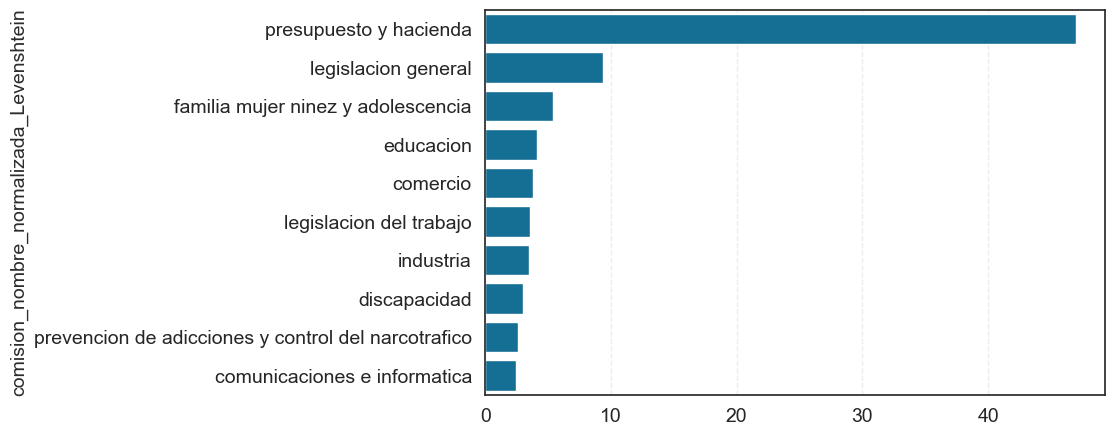

In [47]:
ax= sns.barplot(
    x=com_salud_rel.values[0:10],
    y=com_salud_rel.index[0:10],
    color="#0077A8"
)

ax

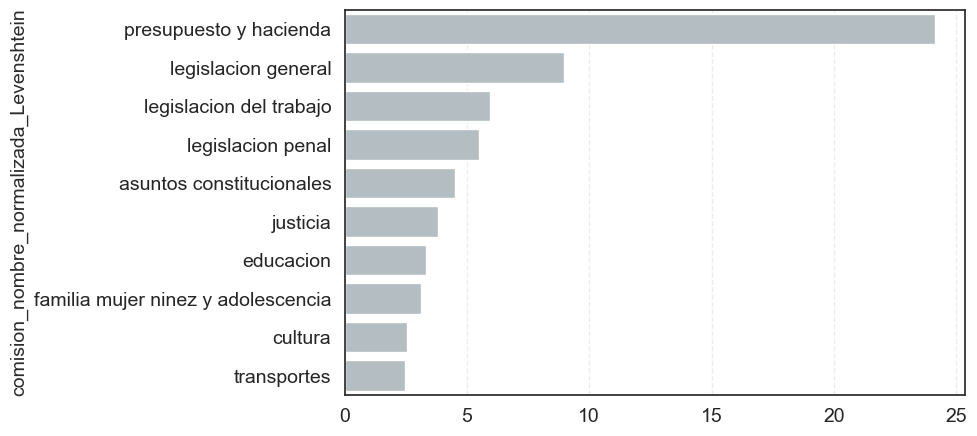

In [48]:
ax= sns.barplot(
    x=com_nosalud_rel.values[0:10],
    y=com_nosalud_rel.index[0:10],
    color="#b0bec5"
)


In [49]:
tabla = pd.crosstab(
    ley_com_df2["comision_nombre_normalizada_Levenshtein"],
    ley_com_df2["Proyecto_SALUD"]
)
tabla_pct = tabla.div(tabla.sum(axis=0), axis=1) * 100
tabla_pct["diferencia"] = tabla_pct[1] - tabla_pct[0]
tabla_pct.sort_values("diferencia", ascending=False).head(10)

Proyecto_SALUD,0.0,1.0,diferencia
comision_nombre_normalizada_Levenshtein,,,
presupuesto y hacienda,24.128344,46.956088,22.827744
industria,1.055862,3.493014,2.437152
comercio,1.487322,3.817365,2.330043
familia mujer ninez y adolescencia,3.120490,5.389222,2.268732
prevencion de adicciones y control del narcotrafico,0.755055,2.619760,1.864705
discapacidad,1.374899,3.043912,1.669013
familias ninez y juventudes,0.569710,1.996008,1.426298
educacion,3.345335,4.116766,0.771431
legislacion general,8.945202,9.356287,0.411086


In [50]:
top10 = tabla_pct.sort_values("diferencia", ascending=False).head(10)
plot_df = top10[[0,1]]
plot_df = top10[[0,1]].reset_index()
plot_df.columns = ["Comision", "No salud", "Salud"]
plot_df = plot_df.melt(
    id_vars="Comision",
    value_vars=["No salud", "Salud"],
    var_name="Tipo de proyecto",
    value_name="Porcentaje"
)
plot_df

,Comision,Tipo de proyecto,Porcentaje
0,presupuesto y hacienda,No salud,24.128344
1,industria,No salud,1.055862
2,comercio,No salud,1.487322
3,familia mujer ninez y adolescencia,No salud,3.120490
4,prevencion de adicciones y control del narcotrafico,No salud,0.755055
5,discapacidad,No salud,1.374899
6,familias ninez y juventudes,No salud,0.569710
7,educacion,No salud,3.345335
8,legislacion general,No salud,8.945202
9,de las personas mayores,No salud,0.306884


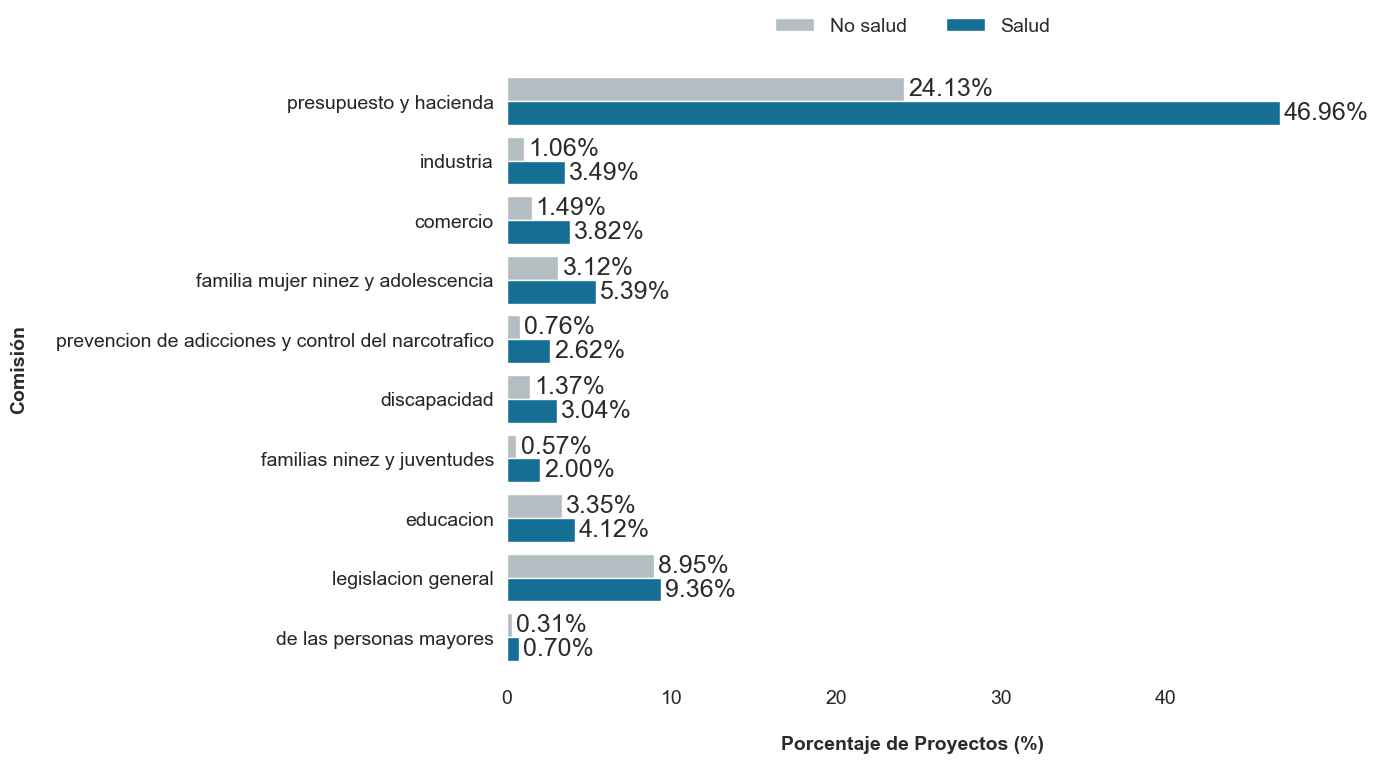

In [51]:
fig, ax = plt.subplots(figsize=(14, 8), facecolor='white')


ax = sns.barplot(
    data=plot_df,
    y="Comision",
    x="Porcentaje",
    hue="Tipo de proyecto",
    palette=["#b0bec5", "#0077A8"]
)

# Agregar etiquetas de porcentaje
for container in ax.containers:
    labels = [locale.format_string('%.2f', v) + "%" for v in container.datavalues]
    ax.bar_label(
        container,
        labels=labels,
        label_type="edge",
        padding=3,
        fontsize=18
    )

ax.tick_params(axis='x', which='major', labelsize=14, pad=10)  # Más espacio entre labels y eje
ax.tick_params(axis='y', labelsize=14)
#ax.set_title("Top 10 Comisiones por Frecuencia Relativa (%) en donde giran los Proyectos de ley", pad=20, fontsize=14)
ax.set_xlabel("Porcentaje de Proyectos (%)", fontsize=14, fontweight='bold', labelpad=20)
ax.set_ylabel("Comisión", fontsize=14, fontweight='bold', labelpad=20)


# Leyenda centrada debajo del título del primer eje
handles, labels = ax.get_legend_handles_labels()

legend  = ax.legend(handles, labels,
             loc='upper center',
             bbox_to_anchor=(0.5, 1.12),  # justo debajo del título
             ncol=3,
             fontsize=14,
             frameon=False)
legend.get_frame().set_linewidth(0)
legend.get_frame().set_edgecolor("none")
legend.get_frame().set_facecolor("none")


# ----- LIMPIAR ESTÉTICA -----
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()


Especialización institucional: Qué comisiones tratan proporcionalmente más salud que otros temas.

Proyecto_SALUD 	0.0 	1.0 	diferencia
comision_nombre_normalizada_Levenshtein 			
presupuesto y hacienda 	24.128344 	46.956088 	22.827744
industria 	1.055862 	3.493014 	2.437152
comercio 	1.487322 	3.817365 	2.330043
familia mujer ninez y adolescencia 	3.120490 	5.389222 	2.268732
prevencion de adicciones y control del narcotrafico 	0.755055 	2.619760 	1.864705
discapacidad 	1.374899 	3.043912 	1.669013
familias ninez y juventudes 	0.569710 	1.996008 	1.426298
educacion 	3.345335 	4.116766 	0.771431
legislacion general 	8.945202 	9.356287 	0.411086
de las personas mayores 	0.306884 	0.698603 	0.391719


In [52]:
tabla

Proyecto_SALUD,0.0,1.0
comision_nombre_normalizada_Levenshtein,,
agricultura ganaderia y pesca,43,2
agricultura y ganaderia,1498,21
ambiente y desarrollo sustentable,35,1
asuntos administrativos y municipales,56,1
asuntos constitucionales,2975,8
...,...,...
tercera edad,29,1
trabajo y prevision social,117,7
transportes,1639,34


Interpretación:

p < 0.05 → hay asociación

las comisiones no reciben proyectos al azar.

Esto responde:

Existe una relación entre tipo de proyecto y comisión.

In [53]:
from scipy.stats import chi2_contingency

chi2, p, dof, exp = chi2_contingency(tabla)
print("Chi2:", chi2)
print("p-value:", p)

Chi2: 2720.3357177058797
p-value: 0.0


Medir la fuerza de la relación (Cramér's V)

El chi-cuadrado solo dice si hay relación, no cuán fuerte es.

In [54]:
import numpy as np

n = tabla.sum().sum()
k = min(tabla.shape)

cramers_v = np.sqrt(chi2/(n*(k-1)))
cramers_v

0.19737271775456114

Interpretación:

V	fuerza
0.1	débil
0.3	moderada
0.5	fuerte

3. Identificar qué comisiones explican la diferencia

Para saber qué comisiones están asociadas a salud, se usan residuos estandarizados del chi-cuadrado.

In [55]:
residuals = (tabla - exp) / np.sqrt(exp)
residuals

Proyecto_SALUD,0.0,1.0
comision_nombre_normalizada_Levenshtein,,
agricultura ganaderia y pesca,0.089486,-0.362643
agricultura y ganaderia,1.749081,-7.088184
ambiente y desarrollo sustentable,0.183038,-0.741765
asuntos administrativos y municipales,0.309900,-1.255874
asuntos constitucionales,3.077933,-12.473380
...,...,...
tercera edad,0.135748,-0.550123
trabajo y prevision social,0.010828,-0.043882
transportes,1.561853,-6.329440


Interpretación:

valor	interpretación
> 2	más casos de los esperados
< -2	menos casos de los esperados

Esto muestra especialización institucional.

ignificado de los Valores:
Residuo 

>2 : Hay significativamente más observaciones que las esperadas (asociación positiva o atracción).
Residuo 

<-2: Hay significativamente menos observaciones que las esperadas (asociación negativa o rechazo).
Residuo cercano a 
0: Indica que la frecuencia observada es muy similar a la esperada, sugiriendo independencia en esa celda.


In [56]:
residuals

Proyecto_SALUD,0.0,1.0
comision_nombre_normalizada_Levenshtein,,
agricultura ganaderia y pesca,0.089486,-0.362643
agricultura y ganaderia,1.749081,-7.088184
ambiente y desarrollo sustentable,0.183038,-0.741765
asuntos administrativos y municipales,0.309900,-1.255874
asuntos constitucionales,3.077933,-12.473380
...,...,...
tercera edad,0.135748,-0.550123
trabajo y prevision social,0.010828,-0.043882
transportes,1.561853,-6.329440


In [57]:
residuals[1].sort_values(ascending=False).head(10) # → estas comisiones reciben más proyectos de salud de lo esperado.

comision_nombre_normalizada_Levenshtein
presupuesto y hacienda                                                    27.009093
industria                                                                 13.300157
prevencion de adicciones y control del narcotrafico                       11.984760
comercio                                                                  10.920893
familias ninez y juventudes                                               10.544405
discapacidad                                                               8.212811
familia mujer ninez y adolescencia                                         7.509095
de las personas mayores                                                    4.073130
bicameral de los derechos de las ninas ninos y adolescentes ley numero     3.934501
justicia y asuntos penales                                                 3.130227
Name: 1.0, dtype: float64

In [58]:
#residuals.abs().sum(axis=1).sort_values(ascending=False)
top20 = residuals.abs().sum(axis=1).sort_values(ascending=False).head(20).index
top20

Index(['presupuesto y hacienda', 'industria', 'asuntos constitucionales',
       'prevencion de adicciones y control del narcotrafico', 'comercio',
       'legislacion penal', 'familias ninez y juventudes', 'justicia',
       'cultura', 'discapacidad', 'prevision y seguridad social',
       'familia mujer ninez y adolescencia', 'agricultura y ganaderia',
       'energia y combustibles', 'relaciones exteriores y culto',
       'recursos naturales y conservacion del ambiente humano',
       'seguridad interior', 'finanzas', 'transportes',
       'legislacion del trabajo'],
      dtype='object', name='comision_nombre_normalizada_Levenshtein')

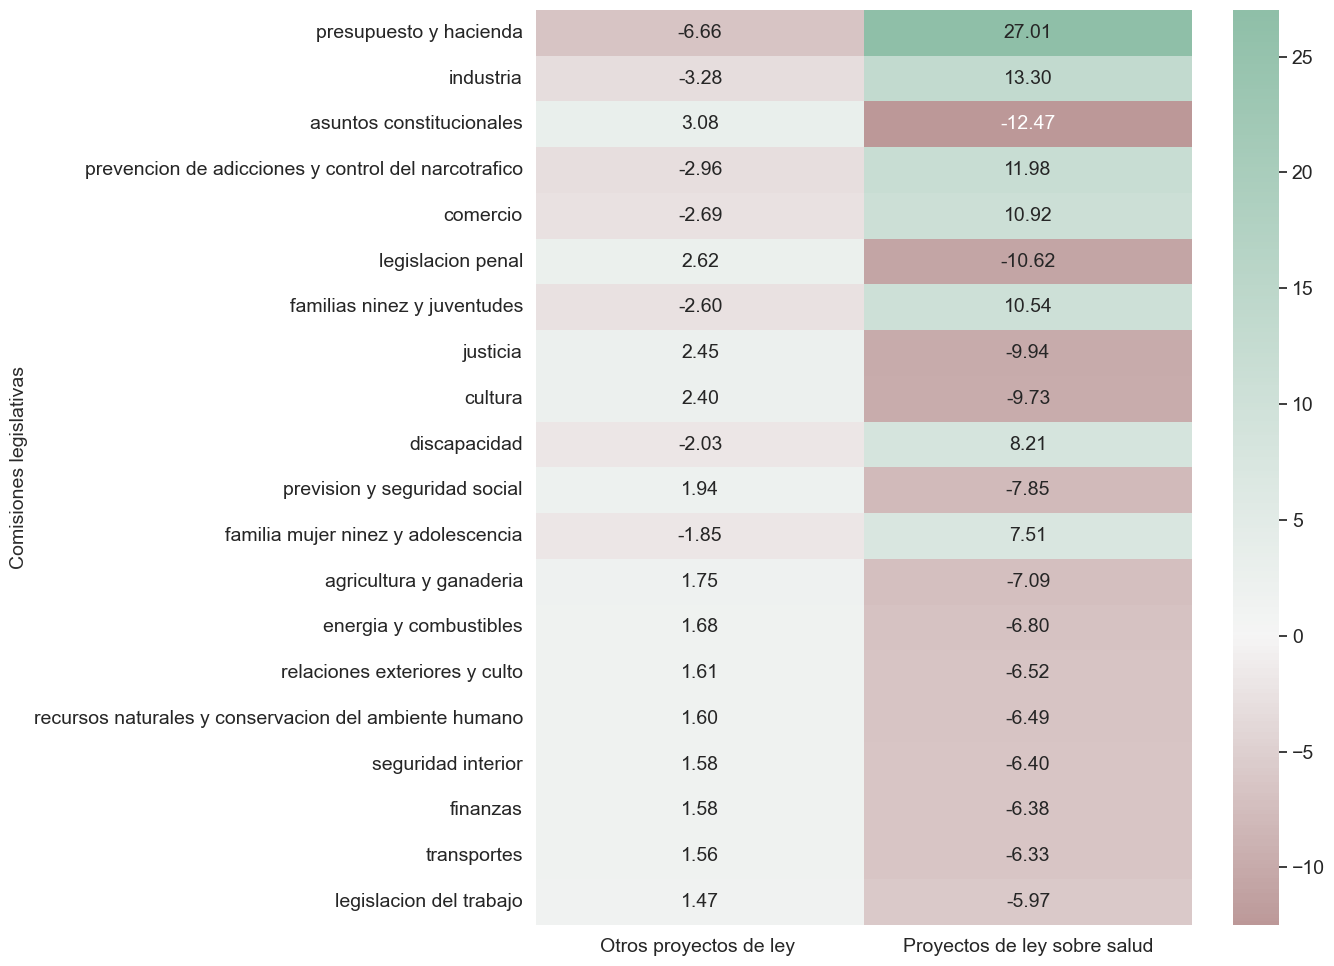

In [59]:
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import LinearSegmentedColormap

residuals_top20 = residuals.loc[top20]

RED_HEALTH   = "#7A2E2E"
GREEN_HEALTH = "#8FBFA8"

# Colormap personalizado
custom_cmap = LinearSegmentedColormap.from_list(
    "health_map",
    [RED_HEALTH, "#F5F5F5", GREEN_HEALTH]
)




plt.figure(figsize=(14, 10))

ax = sns.heatmap(
    residuals_top20,
   cmap=custom_cmap,
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size":14}
)

# Convertir punto decimal a coma
def comma_formatter(x, pos):
    return f"{x:.2f}"#.replace(".", ",")

ax.xaxis.set_major_formatter(FuncFormatter(comma_formatter))

# Etiquetas de ejes
ax.set_xlabel("", fontsize=14)
ax.set_ylabel("Comisiones legislativas", fontsize=14)

# Etiquetas específicas eje X
ax.set_xticklabels(
    ["Otros proyectos de ley ", "Proyectos de ley sobre salud"],
    rotation=0
)

# Quitar grid
ax.grid(False)

# Ocultar bordes superiores y derechos
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Mantener bordes izquierdo e inferior
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')

# Tamaño de etiquetas
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x', labelsize=14)

plt.tight_layout()

plt.savefig(
    BASE_DIR + "imagenes/residuos_estandarizados.png",
    dpi=300,
    bbox_inches='tight',
    facecolor='white',
    edgecolor='none'
)

plt.show()

Rojo → más de lo esperado
Azul → menos de lo esperado.

Existe una asociación estadísticamente significativa entre el tipo de proyecto legislativo y la comisión a la que es girado.

In [60]:
salud_com_df2 = ley_com_df2[ley_com_df2["Proyecto_SALUD"]==1].copy()

tabla = pd.crosstab(
    salud_com_df2["comision_nombre_normalizada_Levenshtein"],
    salud_com_df2["Proyecto_MSE"]
)
tabla_pct = tabla.div(tabla.sum(axis=0), axis=1) * 100
tabla_pct["diferencia"] = tabla_pct[1] - tabla_pct[0]
tabla_pct.sort_values("diferencia", ascending=False)

Proyecto_MSE,0,1,diferencia
comision_nombre_normalizada_Levenshtein,,,
presupuesto y hacienda,46.697154,61.111111,14.413957
educacion,3.912602,15.277778,11.365176
deportes,0.533537,4.166667,3.633130
transportes,0.813008,2.777778,1.964770
banca de la mujer,0.025407,1.388889,1.363482
justicia y asuntos penales,0.254065,1.388889,1.134824
familias ninez y juventudes,1.981707,2.777778,0.796070
industria y comercio,0.025407,0.000000,-0.025407
cultura,0.025407,0.000000,-0.025407


In [61]:
top10 = tabla_pct.sort_values("diferencia", ascending=False).head(10)
plot_df2 = top10[[0,1]]
plot_df2 = top10[[0,1]].reset_index()
plot_df2.columns = ["Comision", "No muerte súbita especifico", "muerte súbita especifico"]
plot_df2 = plot_df2.melt(
    id_vars="Comision",
    value_vars=["No muerte súbita especifico", "muerte súbita especifico"],
    var_name="Tipo de proyecto",
    value_name="Porcentaje"
)
plot_df2

,Comision,Tipo de proyecto,Porcentaje
0,presupuesto y hacienda,No muerte súbita especifico,46.697154
1,educacion,No muerte súbita especifico,3.912602
2,deportes,No muerte súbita especifico,0.533537
3,transportes,No muerte súbita especifico,0.813008
4,banca de la mujer,No muerte súbita especifico,0.025407
5,justicia y asuntos penales,No muerte súbita especifico,0.254065
6,familias ninez y juventudes,No muerte súbita especifico,1.981707
7,industria y comercio,No muerte súbita especifico,0.025407
8,cultura,No muerte súbita especifico,0.025407
9,mineria,No muerte súbita especifico,0.025407


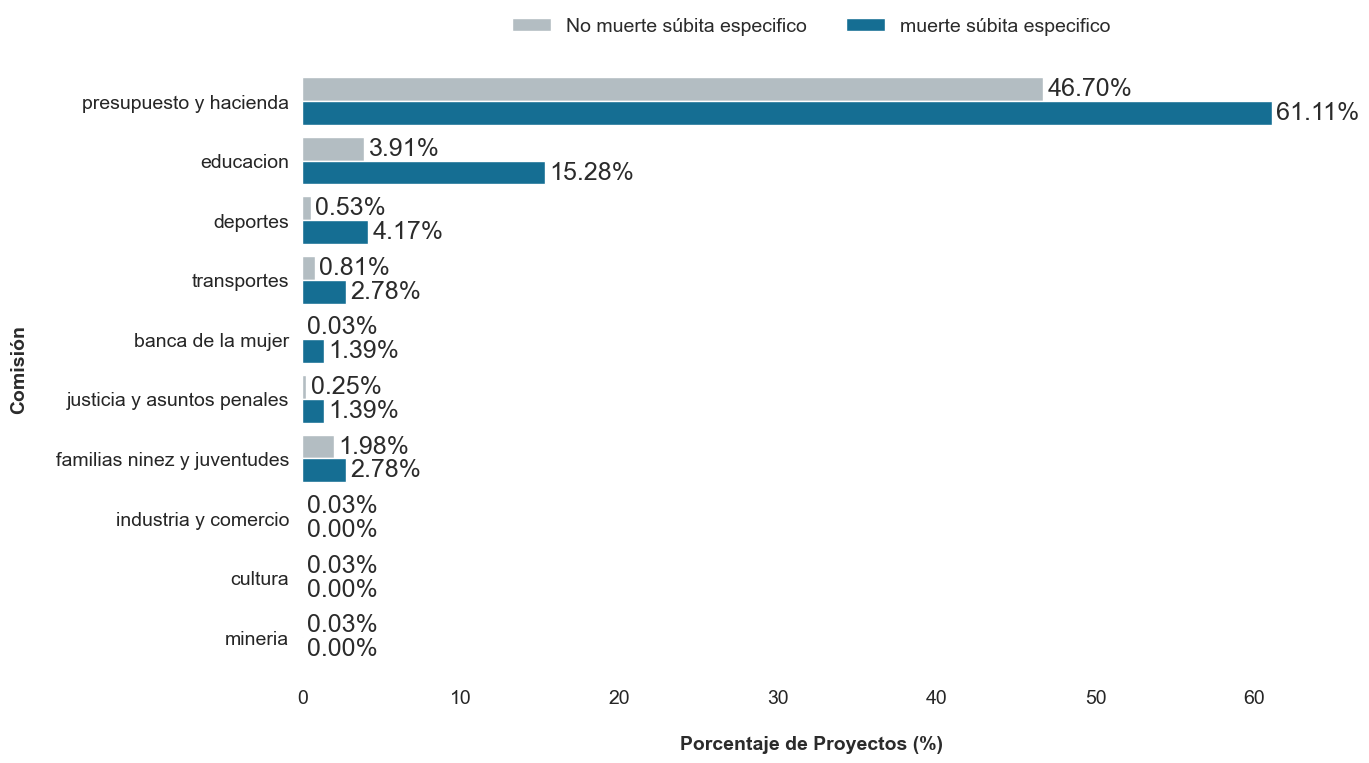

In [62]:
fig, ax = plt.subplots(figsize=(14, 8), facecolor='white')


ax = sns.barplot(
    data=plot_df2,
    y="Comision",
    x="Porcentaje",
    hue="Tipo de proyecto",
    palette=["#b0bec5", "#0077A8"]
)

# Agregar etiquetas de porcentaje
for container in ax.containers:
    labels = [locale.format_string('%.2f', v) + "%" for v in container.datavalues]
    ax.bar_label(
        container,
        labels=labels,
        label_type="edge",
        padding=3,
        fontsize=18
    )

ax.tick_params(axis='x', which='major', labelsize=14, pad=10)  # Más espacio entre labels y eje
ax.tick_params(axis='y', labelsize=14)
#ax.set_title("Top 10 Comisiones por Frecuencia Relativa (%) en donde giran los Proyectos de ley", pad=20, fontsize=14)
ax.set_xlabel("Porcentaje de Proyectos (%)", fontsize=14, fontweight='bold', labelpad=20)
ax.set_ylabel("Comisión", fontsize=14, fontweight='bold', labelpad=20)


# Leyenda centrada debajo del título del primer eje
handles, labels = ax.get_legend_handles_labels()

legend  = ax.legend(handles, labels,
             loc='upper center',
             bbox_to_anchor=(0.5, 1.12),  # justo debajo del título
             ncol=3,
             fontsize=14,
             frameon=False)
legend.get_frame().set_linewidth(0)
legend.get_frame().set_edgecolor("none")
legend.get_frame().set_facecolor("none")


# ----- LIMPIAR ESTÉTICA -----
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()


El test χ² es válido si se cumple:

ninguna celda tiene frecuencia esperada < 1

al menos 80 % de las celdas tienen frecuencia esperada ≥ 5

In [63]:
chi2, p, dof, exp = chi2_contingency(tabla)
print("Chi2:", chi2)
print("p-value:", p)

Chi2: 95.67196014365614
p-value: 0.00041109838587906735


In [64]:
print(exp)

[[1.96407186e+00 3.59281437e-02]
 [2.06227545e+01 3.77245509e-01]
 [9.82035928e-01 1.79640719e-02]
 [9.82035928e-01 1.79640719e-02]
 [7.85628743e+00 1.43712575e-01]
 [2.94610778e+00 5.38922156e-02]
 [2.94610778e+00 5.38922156e-02]
 [1.96407186e+00 3.59281437e-02]
 [9.82035928e-01 1.79640719e-02]
 [1.08023952e+01 1.97604790e-01]
 [6.87425150e+00 1.25748503e-01]
 [1.50251497e+02 2.74850299e+00]
 [9.52574850e+01 1.74251497e+00]
 [9.82035928e-01 1.79640719e-02]
 [2.74970060e+01 5.02994012e-01]
 [4.22275449e+01 7.72455090e-01]
 [4.91017964e+00 8.98203593e-02]
 [2.35688623e+01 4.31137725e-01]
 [2.35688623e+01 4.31137725e-01]
 [9.82035928e-01 1.79640719e-02]
 [1.19808383e+02 2.19161677e+00]
 [2.94610778e+00 5.38922156e-02]
 [4.91017964e+00 8.98203593e-02]
 [1.62035928e+02 2.96407186e+00]
 [4.91017964e+00 8.98203593e-02]
 [2.94610778e+00 5.38922156e-02]
 [2.12119760e+02 3.88023952e+00]
 [7.85628743e+01 1.43712575e+00]
 [1.27664671e+01 2.33532934e-01]
 [1.37485030e+02 2.51497006e+00]
 [9.820359

In [65]:

n = tabla.sum().sum()
k = min(tabla.shape)

cramers_v = np.sqrt(chi2/(n*(k-1)))
cramers_v

0.15449999850110147

In [66]:
com_salud_rel  # Top 10

comision_nombre_normalizada_Levenshtein
presupuesto y hacienda                                                    46.96
legislacion general                                                        9.36
familia mujer ninez y adolescencia                                         5.39
educacion                                                                  4.12
comercio                                                                   3.82
legislacion del trabajo                                                    3.54
industria                                                                  3.49
discapacidad                                                               3.04
prevencion de adicciones y control del narcotrafico                        2.62
comunicaciones e informatica                                               2.42
familias ninez y juventudes                                                2.00
legislacion penal                                                          1.42


In [67]:
salud_com_df2["comision_simple"] = salud_com_df2[
    "comision_nombre_normalizada_Levenshtein"
].where(
    salud_com_df2["comision_nombre_normalizada_Levenshtein"].isin(
        ["presupuesto y hacienda", "educacion"]
    ),
    "otro"
)
tabla = pd.crosstab(
    salud_com_df2["comision_simple"],
    salud_com_df2["Proyecto_MSE"]
)

In [68]:
tabla

Proyecto_MSE,0,1
comision_simple,,
educacion,154,11
otro,1944,17
presupuesto y hacienda,1838,44


In [69]:
chi2, p, dof, exp = chi2_contingency(tabla)
print("Chi2:", chi2)
print("p-value:", p)
print(exp)

Chi2: 34.91718833220838
p-value: 2.617151670798477e-08
[[ 162.03592814    2.96407186]
 [1925.77245509   35.22754491]
 [1848.19161677   33.80838323]]


In [70]:
residuals = (tabla - exp) / np.sqrt(exp)
residuals

Proyecto_MSE,0,1
comision_simple,,
educacion,-0.631292,4.667579
otro,0.415361,-3.071051
presupuesto y hacienda,-0.237066,1.752794


<Axes: xlabel='Proyecto_MSE', ylabel='comision_simple'>

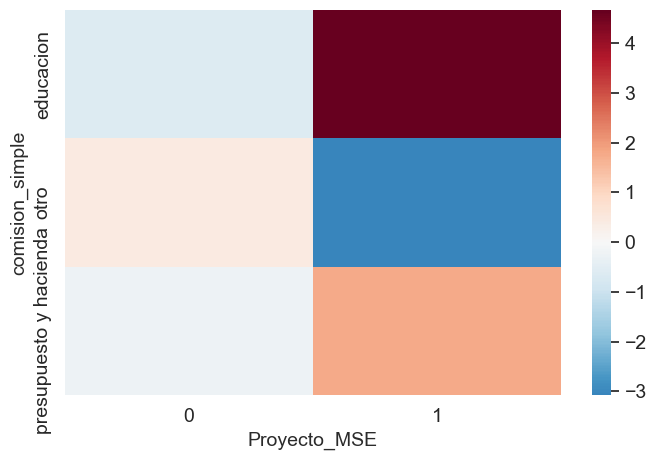

In [71]:
sns.heatmap(residuals, cmap="RdBu_r", center=0)

Se analizo los top 2 y otros Analizar solo las top comisiones



 En la exploracion no se observa las comisiones mineria tu y turismo asociadas a proyectos de muerte subita, actividades que son de interes para 9amas en su impacto en el norte. En base a la informacion diponible,  compete a la Comisión de Minería dictaminar sobre lo relativo al régimen y fomento de la minería en todas sus manifestaciones, tanto de la actividad primaria hasta la de elaboración; fiscalización de procesos afines; estudios e investigaciones tecnológicas; certificación de calidad; procedimiento y volúmenes de producción; necesidades del mercado; análisis y control de la política crediticia y de fomento minero; instalación, desarrollo y actividades de agencias de promoción y comercialización minera; instalación y funcionamiento del parque minero; organizaciones económicas y profesionales vinculadas a la producción minera; cooperativas mineras, su incrementación y desarrollo; exposiciones y ferias mineras; publicaciones, intercambios y demás actividades tendientes al fomento minero, así como en cualquier otro de legislación relacionado con dicha materia. Para citar https://hcdn.gob.ar/comisiones/permanentes/cmineria/competencia.html

En cuanto a turismo Compete a la Comisión de Turismo dictaminar sobre todo asunto o proyecto vinculado a la promoción y fomento de las actividades turísticas, como también en todo aquello vinculado a la formulación de las normas legislativas que regulen su funcionamiento. Para citar https://hcdn.gob.ar/comisiones/permanentes/cturismo/competencia.html
